# Tratamento dos dados

Dado que uma rede MLP espera como entrada um vetor unidimensional de características, é necessário adequar a representação das imagens da base de dados para esse formato.

Para isso, aplicaram-se as seguintes etapas de pré-processamento:

1. Conversão das imagens de RGB para escala de cinza, removendo os canais de cor e mantendo apenas a intensidade dos pixels, o que reduz a dimensionalidade dos dados.

2. *Flatten* das imagens para representação em linha, transformando a matriz bidimensional da imagem em um vetor unidimensional de características.

In [33]:
# Imports

from keras.datasets import cifar10
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.utils import set_random_seed, to_categorical
from keras.optimizers import Adam

set_random_seed(259)

In [34]:
# Carregamento dos dados

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print('Train Images Shape:      ', x_train.shape)
print('Train Labels Shape:      ', y_train.shape)

print('\nTest Images Shape:       ', x_test.shape)
print('Test Labels Shape:       ', y_test.shape)

Train Images Shape:       (50000, 32, 32, 3)
Train Labels Shape:       (50000, 1)

Test Images Shape:        (10000, 32, 32, 3)
Test Labels Shape:        (10000, 1)


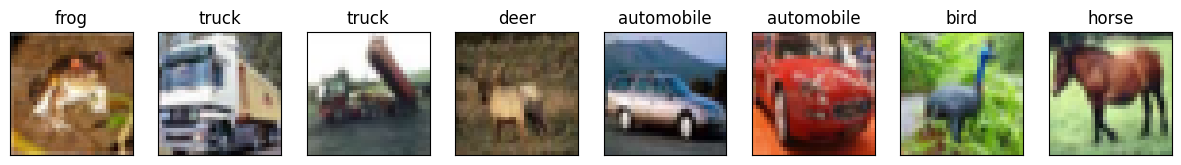

In [35]:
# Exemplos de imagens

# Classes
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(15,15))

# Loop over the first 8 images
for i in range(8):
    # Create a subplot for each image
    plt.subplot(8, 8, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    # Display the image
    plt.imshow(x_train[i])

    # Set the label as the title
    plt.title(class_names[y_train[i][0]], fontsize=12)

# Display the figure
plt.show()

In [36]:
# Conversão das imagens de RGB para escala de cinza

# fórmula padrão: Y = 0.299 R + 0.587 G + 0.114 B
x_train_gray = np.dot(x_train[..., :3], [0.299, 0.587, 0.114])
x_test_gray = np.dot(x_test[..., :3], [0.299, 0.587, 0.114])

print('Train Images Shape (Gray scale):      ', x_train_gray.shape)
print('Test Images Shape (Gray scale):       ', x_test_gray.shape)

Train Images Shape (Gray scale):       (50000, 32, 32)
Test Images Shape (Gray scale):        (10000, 32, 32)


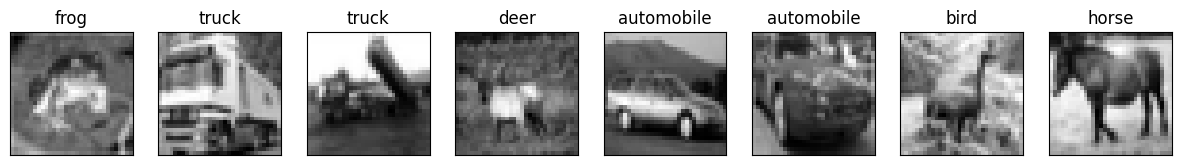

In [37]:
# Exemplos de imagens

# Classes
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(15,15))

# Loop over the first 8 images
for i in range(8):
    # Create a subplot for each image
    plt.subplot(8, 8, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    # Display the image
    plt.imshow(x_train_gray[i], cmap='gray')

    # Set the label as the title
    plt.title(class_names[y_train[i][0]], fontsize=12)

# Display the figure
plt.show()

In [38]:
# Flatten das imagens e normalização [0, 1] (melhora estabilidade e acurácia)

x_train_flat = x_train_gray.reshape(x_train_gray.shape[0], -1).astype('float32') / 255.0
x_test_flat = x_test_gray.reshape(x_test_gray.shape[0], -1).astype('float32') / 255.0

x_train_df = pd.DataFrame(x_train_flat)
x_test_df = pd.DataFrame(x_test_flat)

print('Train Images Shape (Gray scale & Flatten):      ', x_train_df.shape)
print('Test Images Shape (Gray scale & Flatten):       ', x_test_df.shape)

# Conversão dos rótulos para one-hot encoding

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

Train Images Shape (Gray scale & Flatten):       (50000, 1024)
Test Images Shape (Gray scale & Flatten):        (10000, 1024)


# Estrutura da rede

In [39]:
# Hiper-parâmetros

input_shape = 1024                  # 32 x 32 x 1
epochs = 50                         # https://keras.io/examples/vision/mlp_image_classification/
batch_size = 128                    # https://wandb.ai/sulbing/CIFAR10/reports/CIFAR10-Only-MLP-Not-CNN---Vmlldzo1NjkyNjMw
dropout_rate = 0.2                  # https://keras.io/examples/vision/mlp_image_classification/
learning_rate = 0.001               # https://wandb.ai/sulbing/CIFAR10/reports/CIFAR10-Only-MLP-Not-CNN---Vmlldzo1NjkyNjMw

#Outras Fontes
#https://pvss.github.io/MLP+of+CIFAR-10
#https://www.kaggle.com/code/yorkyong/exploring-cifar-10-w-mlp-cnn-resnet

In [40]:
# Construção do modelo MLP

# Estutura baseada no artigo
# "UTILIZAÇÃO DE REDES NEURAIS ARTIFICIAIS PARA A CLASSIFICAÇÃO DECORROSÃO POR PITE OBSERVADAS EM IMAGENS OBTIDAS COM O ENSAIO NÃO INVASIVO DE QUEDA DE POTENCIAL"
# de GABRIEL PEREIRA HOLANDA BARRETO (https://repositorio.ufc.br/bitstream/riufc/83115/1/2025_tcc_gphbarreto.pdf)

def create_model_1():

    model = Sequential([
        Dense(32, activation='relu', input_shape=(input_shape,)),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )

    return model

# Experimento 1 - Sem dropout e sem early stop

In [41]:
histories = []
train_accuracies = []
test_losses = []
test_accuracies = []

for i in range(3):
    model_1 = create_model_1()

    history = model_1.fit(
        x_train_df.values,
        y_train_cat,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.1,
        verbose=1,
    )

    histories.append(history)

    train_acc = history.history['accuracy'][-1] 
    train_accuracies.append(train_acc)          

    loss, acc = model_1.evaluate(
        x_test_df.values,
        y_test_cat,
        verbose=0
    )

    test_losses.append(loss)
    test_accuracies.append(acc)

    print(f'Execução {i+1} | Treino — acurácia: {train_acc:.4f} | Teste — loss: {loss:.4f}, acurácia: {acc:.4f}')

Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2340 - loss: 2.0918 - val_accuracy: 0.2824 - val_loss: 2.0202
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2943 - loss: 1.9597 - val_accuracy: 0.3056 - val_loss: 1.9410
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3219 - loss: 1.8966 - val_accuracy: 0.3352 - val_loss: 1.8854
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3357 - loss: 1.8585 - val_accuracy: 0.3424 - val_loss: 1.8509
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3454 - loss: 1.8318 - val_accuracy: 0.3510 - val_loss: 1.8248
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.3557 - loss: 1.8081 - val_accuracy: 0.3530 - val_loss: 1.8113
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3620 - loss: 1.7904 - val_accuracy: 0.3578 - val_loss: 1.8005
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3671 - loss: 1.7770 - val_accuracy: 0.

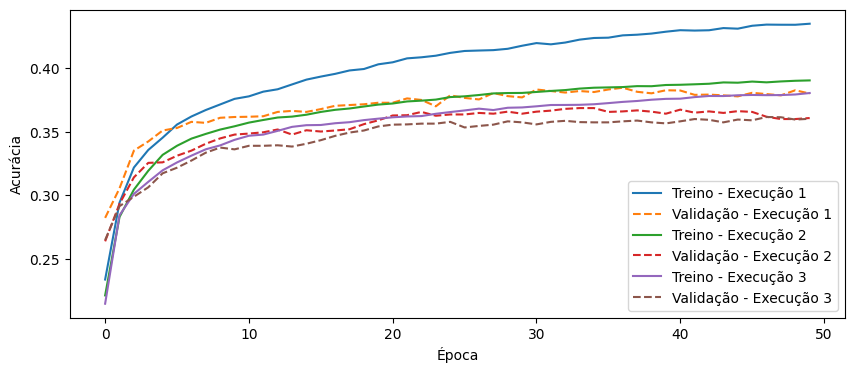

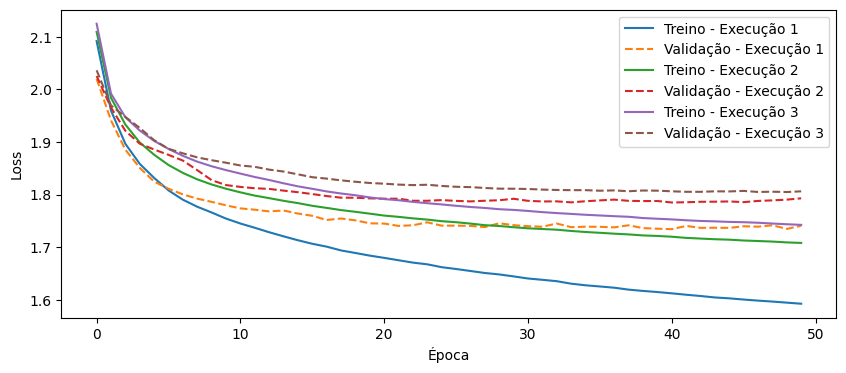

Execução 1:
  Treino — acurácia: 0.4348
  Teste  — loss: 1.7581, acurácia: 0.3757
Execução 2:
  Treino — acurácia: 0.3903
  Teste  — loss: 1.7987, acurácia: 0.3581
Execução 3:
  Treino — acurácia: 0.3804
  Teste  — loss: 1.7994, acurácia: 0.3571


In [42]:
# Acurácia de validação e teste
def show_results(histories, train_accuracies, test_losses, test_accuracies):
    plt.figure(figsize=(10,4))

    for i, history in enumerate(histories):
        plt.plot(history.history['accuracy'], label=f'Treino - Execução {i+1}')
        plt.plot(history.history['val_accuracy'], '--', label=f'Validação - Execução {i+1}')

    plt.xlabel('Época')
    plt.ylabel('Acurácia')
    plt.legend()
    plt.show()

    # Perda de validação e teste

    plt.figure(figsize=(10,4))

    for i, history in enumerate(histories):
        plt.plot(history.history['loss'], label=f'Treino - Execução {i+1}')
        plt.plot(history.history['val_loss'], '--', label=f'Validação - Execução {i+1}')

    plt.xlabel('Época')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    # Resultado do experimento
    for i in range(3):
        print(f'Execução {i+1}:')
        print(f'  Treino — acurácia: {train_accuracies[i]:.4f}')
        print(f'  Teste  — loss: {test_losses[i]:.4f}, acurácia: {test_accuracies[i]:.4f}')

show_results(histories, train_accuracies, test_losses, test_accuracies)

# Experimento 2 - Sem dropout e com early stop

In [43]:
# Treinamento

from keras.callbacks import EarlyStopping

histories = []
train_accuracies = []
test_losses = []
test_accuracies = []

for i in range(3):
    model_1 = create_model_1()

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=5,
    )

    history = model_1.fit(
        x_train_df.values,
        y_train_cat,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.1,
        verbose=1,
        callbacks=[early_stop]
    )

    histories.append(history)

    train_acc = history.history['accuracy'][-1] 
    train_accuracies.append(train_acc)          

    loss, acc = model_1.evaluate(
        x_test_df.values,
        y_test_cat,
        verbose=0
    )

    test_losses.append(loss)
    test_accuracies.append(acc)

    print(f'Execução {i+1} | Treino — acurácia: {train_acc:.4f} | Teste — loss: {loss:.4f}, acurácia: {acc:.4f}')

Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2291 - loss: 2.0943 - val_accuracy: 0.2766 - val_loss: 2.0055
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2958 - loss: 1.9588 - val_accuracy: 0.3082 - val_loss: 1.9365
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3124 - loss: 1.9159 - val_accuracy: 0.3220 - val_loss: 1.9073
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3231 - loss: 1.8888 - val_accuracy: 0.3318 - val_loss: 1.8850
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3322 - loss: 1.8649 - val_accuracy: 0.3344 - val_loss: 1.8693
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3396 - loss: 1.8463 - val_accuracy: 0.3338 - val_loss: 1.8573
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3470 - loss: 1.8318 - val_accuracy: 0.3432 - val_loss: 1.8432
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3524 - loss: 1.8205 - val_accuracy: 0.

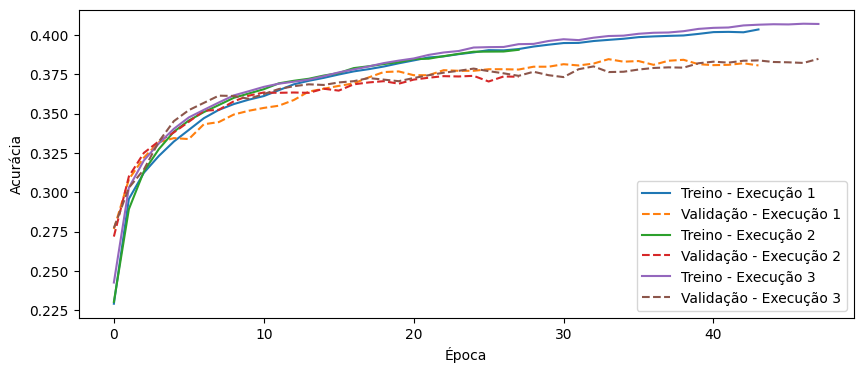

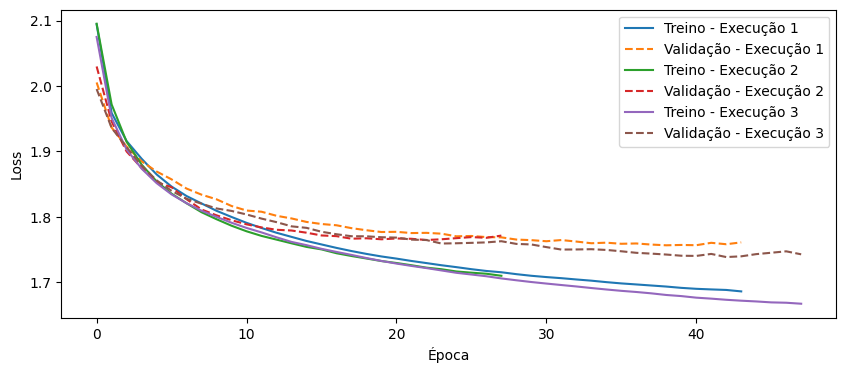

Execução 1:
  Treino — acurácia: 0.4035
  Teste  — loss: 1.7659, acurácia: 0.3760
Execução 2:
  Treino — acurácia: 0.3906
  Teste  — loss: 1.7824, acurácia: 0.3694
Execução 3:
  Treino — acurácia: 0.4070
  Teste  — loss: 1.7538, acurácia: 0.3728


In [44]:
# Resutados
show_results(histories, train_accuracies, test_losses, test_accuracies)

# Experimento 3 - Com dropout e sem early stop

In [45]:
# Treinamento

In [46]:
# Resultados

# Experimento 4 - Com dropout e com early stop

In [47]:
# Treinamento

from keras.callbacks import EarlyStopping

histories_exp4 = []
train_accuracies_exp4 = []
test_losses_exp4 = []
test_accuracies_exp4 = []
epochs_ran_exp4 = []

for i in range(3):

    print(f'Execução {i+1}')

    model_4 = Sequential([
        Dense(256, activation='relu', input_shape=(input_shape,)),
        Dropout(dropout_rate),
        Dense(256, activation='relu'),
        Dropout(dropout_rate),
        Dense(10, activation='softmax')
    ])

    model_4.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=0,
    )

    history = model_4.fit(
        x_train_df.values,
        y_train_cat,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=0,
    )

    histories_exp4.append(history)

    train_acc = max(history.history['accuracy'])
    train_accuracies_exp4.append(train_acc)

    epochs_ran = len(history.history['loss'])
    epochs_ran_exp4.append(epochs_ran)

    loss, acc = model_4.evaluate(
        x_test_df.values,
        y_test_cat,
        verbose=0,
    )

    test_losses_exp4.append(loss)
    test_accuracies_exp4.append(acc)

    print(
        f'Execução {i+1} | Épocas: {epochs_ran} | '
        f'Treino — acurácia máx.: {train_acc:.4f} | '
        f'Teste — loss: {loss:.4f}, acurácia: {acc:.4f}'
    )

In [48]:
# Resultados
print('Resultados do Experimento 4 (Com dropout + com early stop):')
for i in range(3):
    print(f'Execução {i+1}:')
    print(f'  Épocas executadas: {epochs_ran_exp4[i]}')
    print(f'  Treino — acurácia máx.: {train_accuracies_exp4[i]:.4f}')
    print(f'  Teste  — loss: {test_losses_exp4[i]:.4f}, acurácia: {test_accuracies_exp4[i]:.4f}')

print('\nMédia:')
print(f'  Épocas executadas: {np.mean(epochs_ran_exp4):.2f}')
print(f'  Treino — acurácia máx.: {np.mean(train_accuracies_exp4):.4f}')
print(f'  Teste  — loss: {np.mean(test_losses_exp4):.4f}, acurácia: {np.mean(test_accuracies_exp4):.4f}')

# Acurácia de validação e treino
plt.figure(figsize=(10,4))
for i, history in enumerate(histories_exp4):
    plt.plot(history.history['accuracy'], label=f'Treino - Execução {i+1}')
    plt.plot(history.history['val_accuracy'], '--', label=f'Validação - Execução {i+1}')
plt.title('Experimento 4: Acurácia por época')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()
plt.show()

# Loss de validação e treino
plt.figure(figsize=(10,4))
for i, history in enumerate(histories_exp4):
    plt.plot(history.history['loss'], label=f'Treino - Execução {i+1}')
    plt.plot(history.history['val_loss'], '--', label=f'Validação - Execução {i+1}')
plt.title('Experimento 4: Loss por época')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.show()